# Ablation Study: Grayscale, Blur, Text & Crop
Measures how each type of image modification affects predicted memorability.
Each ablation type is scored against its paired original and results are compared.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── DEPENDENCIES ─────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import timm
from PIL import Image
from torchvision import transforms
from scipy import stats

# ── PATHS ─────────────────────────────────────────────────────────────
DATA_PATH   = "/content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission"
CHECKPOINT  = f"{DATA_PATH}/checkpoints/050626_215834_model_epoch3.pth"

# Original images shared across all ablations
ORIG_DIR    = f"{DATA_PATH}/data/lamem_final"

# One folder per ablation type — update these to match your actual folder names
ABLATION_DIRS = {
    "grayscale":   f"{DATA_PATH}/data/ablation_grayscale",
    "whole_blur":  f"{DATA_PATH}/data/ablation_blur",       # whole image blurred
    "text_blur":   f"{DATA_PATH}/data/ablation_text_blur",     # text regions blurred
    "crop":        f"{DATA_PATH}/data/ablation_center_crop",     # center crop
}

RESULTS_DIR = f"{DATA_PATH}/results/ablations"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:
# ── VALIDATE PATHS ───────────────────────────────────────────────────
all_ok = True
for label, path in {"Checkpoint": CHECKPOINT, "Original dir": ORIG_DIR, **ABLATION_DIRS}.items():
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌  NOT FOUND'}  {label}: {path}")
    if not exists:
        all_ok = False
    elif os.path.isdir(path):
        imgs = [f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"   └─ {len(imgs)} images")

if not all_ok:
    raise FileNotFoundError("Fix missing paths above before continuing.")
print("\nAll paths valid ✅")

✅  Checkpoint: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/checkpoints/050626_215834_model_epoch3.pth
✅  Original dir: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/data/lamem_final
   └─ 1000 images
✅  grayscale: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/data/ablation_grayscale
   └─ 1000 images
✅  whole_blur: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/data/ablation_blur
   └─ 1000 images
✅  text_blur: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Project/Public/final_submission/data/ablation_text_blur
   └─ 999 images
✅  crop: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3106_Final_Projec

In [4]:
# ── MODEL ─────────────────────────────────────────────────────────────
class MemorabilityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('resnet50', pretrained=False, num_classes=0)
        self.regressor = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.regressor(self.backbone(x)).squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MemorabilityModel().to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print(f"Model loaded on: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_score(pil_img):
    with torch.no_grad():
        t = transform(pil_img).unsqueeze(0).to(device)
        return model(t).item()

Model loaded on: cuda


In [7]:
# ── SCORE ALL ABLATION TYPES (batched) ──────────────────────────────
from torch.utils.data import DataLoader, Dataset

class ImageFolder(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return transform(img), os.path.basename(self.paths[i])

def score_batch(img_dir, filenames, batch_size=128):
    valid_paths = [os.path.join(img_dir, f) for f in filenames
                   if os.path.exists(os.path.join(img_dir, f))]
    dataset = ImageFolder(valid_paths)
    loader  = DataLoader(dataset, batch_size=batch_size, num_workers=2, pin_memory=True)
    scores  = {}
    model.eval()
    with torch.no_grad():
        for imgs, fnames in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).cpu().numpy()
            for fname, score in zip(fnames, preds):
                scores[fname] = float(score)
    return scores

orig_filenames = sorted([
    f for f in os.listdir(ORIG_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

# Score originals once as shared baseline
print("Scoring originals...")
orig_scores = score_batch(ORIG_DIR, orig_filenames)
print(f"  {len(orig_scores)} done.")

# Score each ablation type
all_results = {}
for name, abl_dir in ABLATION_DIRS.items():
    print(f"Scoring {name}...")
    abl_scores = score_batch(abl_dir, orig_filenames)
    rows = [
        {'filename': f, 'original': orig_scores[f],
         'ablated': abl_scores[f], 'delta': abl_scores[f] - orig_scores[f]}
        for f in orig_filenames if f in abl_scores
    ]
    df = pd.DataFrame(rows)
    all_results[name] = df
    df.to_csv(f"{RESULTS_DIR}/{name}_scores.csv", index=False)
    print(f"  {len(df)} pairs scored. Saved to {name}_scores.csv")

print("\nAll ablations complete ✅")

Scoring originals...
  1000 done.
Scoring grayscale...
  1000 pairs scored. Saved to grayscale_scores.csv
Scoring whole_blur...
  1000 pairs scored. Saved to whole_blur_scores.csv
Scoring text_blur...
  999 pairs scored. Saved to text_blur_scores.csv
Scoring crop...
  1000 pairs scored. Saved to crop_scores.csv

All ablations complete ✅


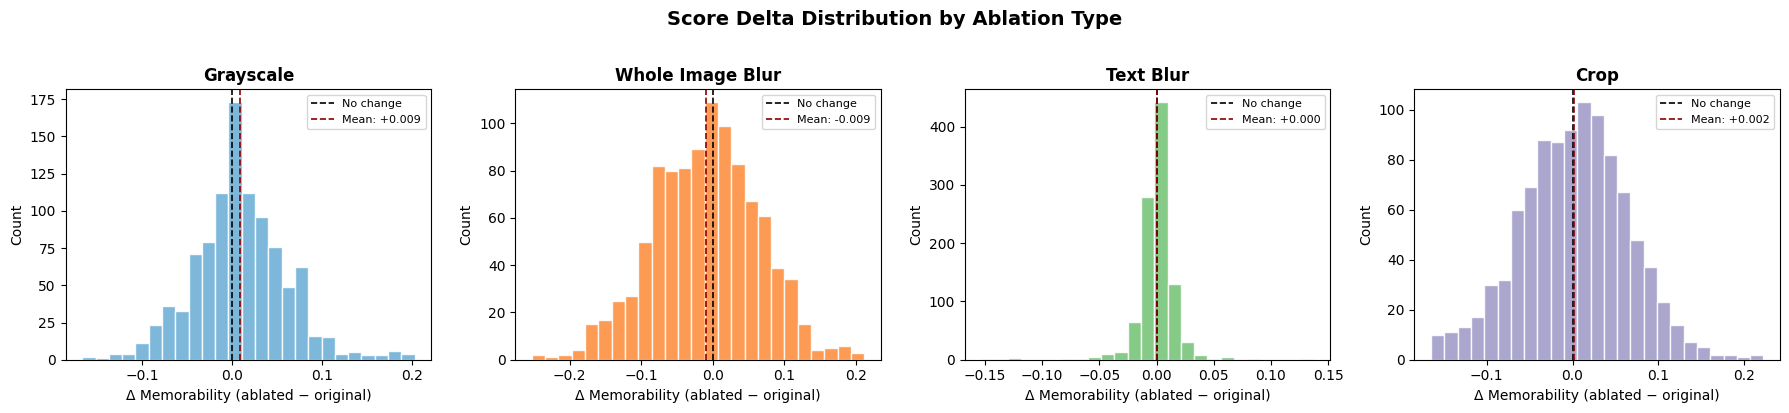

In [8]:
# ── FIGURE 1: Delta distributions — one subplot per ablation type ────
COLORS = {
    'grayscale':  '#6baed6',
    'whole_blur': '#fd8d3c',
    'text_blur':  '#74c476',
    'crop':       '#9e9ac8',
}
LABELS = {
    'grayscale':  'Grayscale',
    'whole_blur': 'Whole Image Blur',
    'text_blur':  'Text Blur',
    'crop':       'Crop',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for ax, (name, df) in zip(axes, all_results.items()):
    ax.hist(df['delta'], bins=25, color=COLORS[name], edgecolor='white', alpha=0.88)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='No change')
    ax.axvline(df['delta'].mean(), color='darkred', linestyle='--', linewidth=1.2,
               label=f"Mean: {df['delta'].mean():+.3f}")
    ax.set_title(LABELS[name], fontsize=12, fontweight='bold')
    ax.set_xlabel('Δ Memorability (ablated − original)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Score Delta Distribution by Ablation Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_delta_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

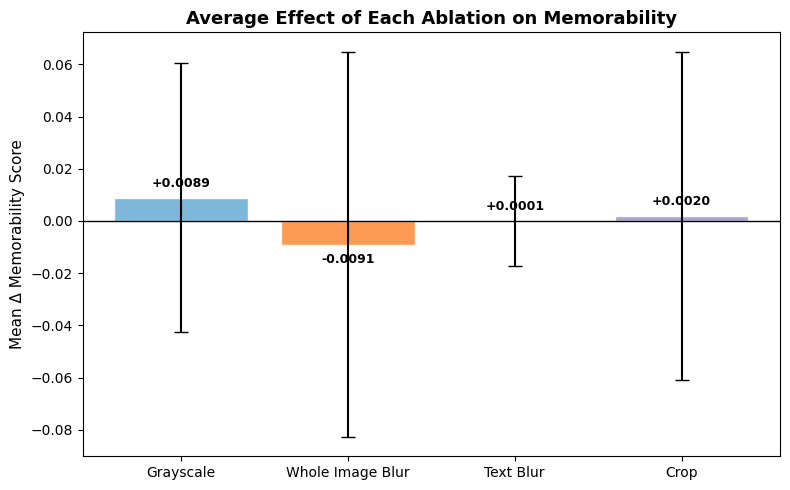

In [9]:
# ── FIGURE 2: Mean delta comparison bar chart ────────────────────────
means  = {LABELS[k]: v['delta'].mean() for k, v in all_results.items()}
stds   = {LABELS[k]: v['delta'].std()  for k, v in all_results.items()}
colors = [COLORS[k] for k in all_results]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(means.keys(), means.values(), yerr=stds.values(),
              color=colors, edgecolor='white', capsize=5, alpha=0.88)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Mean Δ Memorability Score', fontsize=11)
ax.set_title('Average Effect of Each Ablation on Memorability', fontsize=13, fontweight='bold')
for bar, val in zip(bars, means.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (0.003 if val >= 0 else -0.008),
            f'{val:+.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_mean_deltas.png', dpi=150, bbox_inches='tight')
plt.show()

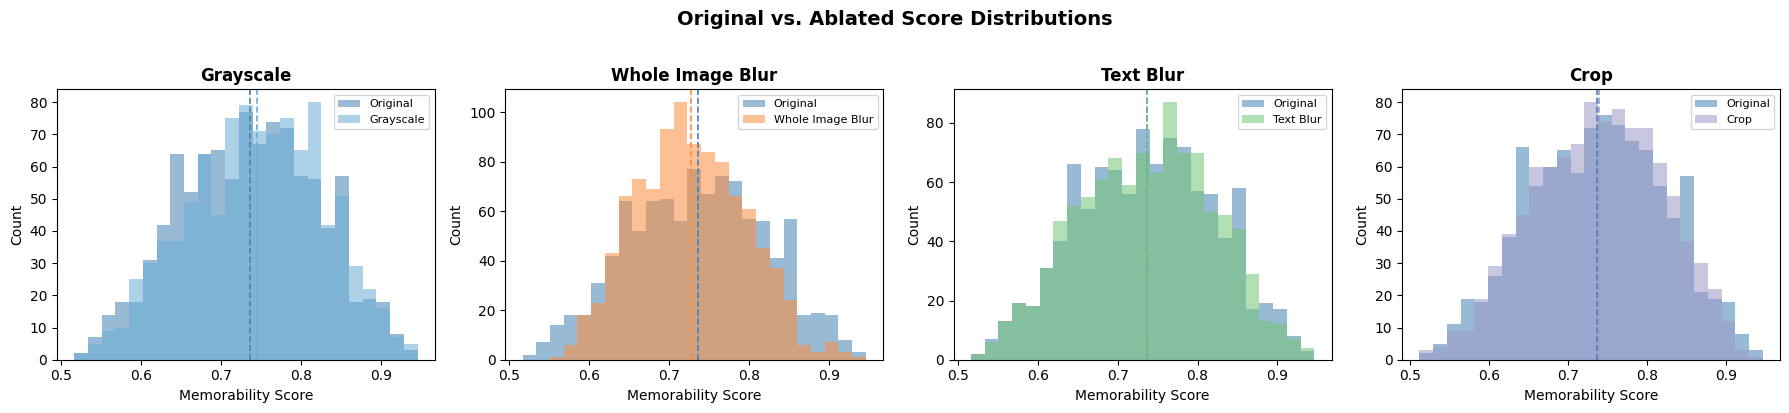

In [10]:
# ── FIGURE 3: Overlaid score distributions (original vs ablated) ─────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, df) in zip(axes, all_results.items()):
    bins = np.linspace(
        min(df['original'].min(), df['ablated'].min()),
        max(df['original'].max(), df['ablated'].max()),
        26
    )
    ax.hist(df['original'], bins=bins, color='steelblue', alpha=0.55, label='Original')
    ax.hist(df['ablated'],  bins=bins, color=COLORS[name], alpha=0.55, label=LABELS[name])
    ax.axvline(df['original'].mean(), color='steelblue', linestyle='--', linewidth=1.2)
    ax.axvline(df['ablated'].mean(),  color=COLORS[name], linestyle='--', linewidth=1.2)
    ax.set_title(LABELS[name], fontsize=12, fontweight='bold')
    ax.set_xlabel('Memorability Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Original vs. Ablated Score Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_overlaid_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

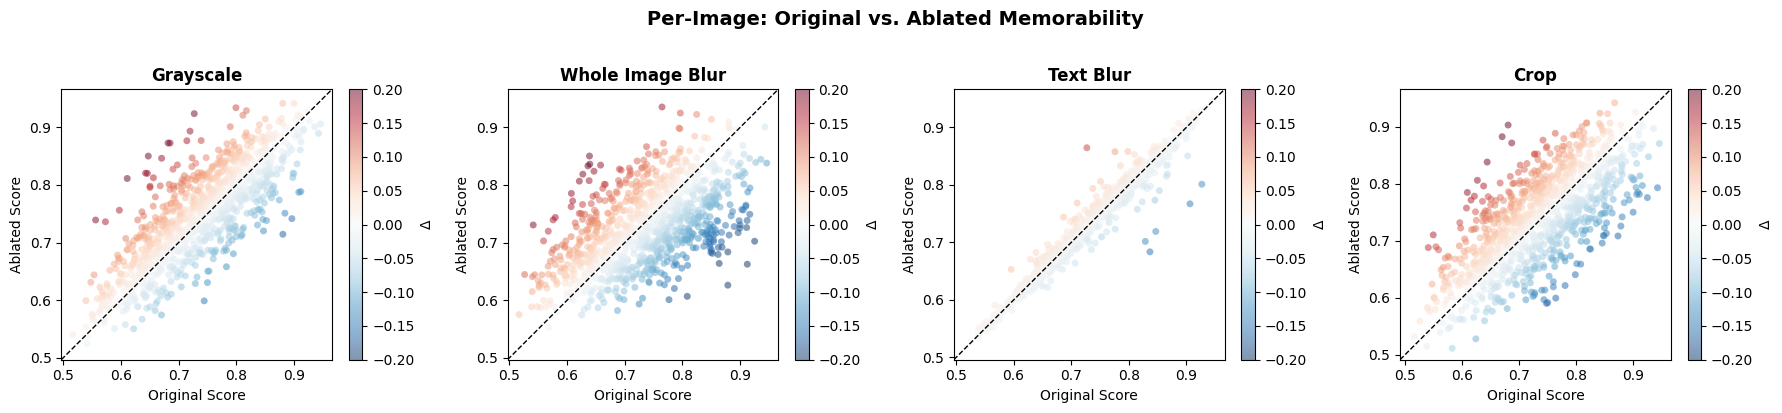

In [11]:
# ── FIGURE 4: Per-image scatter (original vs ablated) ────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, df) in zip(axes, all_results.items()):
    sc = ax.scatter(df['original'], df['ablated'],
                    c=df['delta'], cmap='RdBu_r', vmin=-0.2, vmax=0.2,
                    alpha=0.5, s=25, edgecolors='none')
    lims = [
        min(df[['original','ablated']].min()) - 0.02,
        max(df[['original','ablated']].max()) + 0.02
    ]
    ax.plot(lims, lims, 'k--', linewidth=1, label='No change')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Original Score')
    ax.set_ylabel('Ablated Score')
    ax.set_title(LABELS[name], fontsize=12, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='Δ')

fig.suptitle('Per-Image: Original vs. Ablated Memorability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

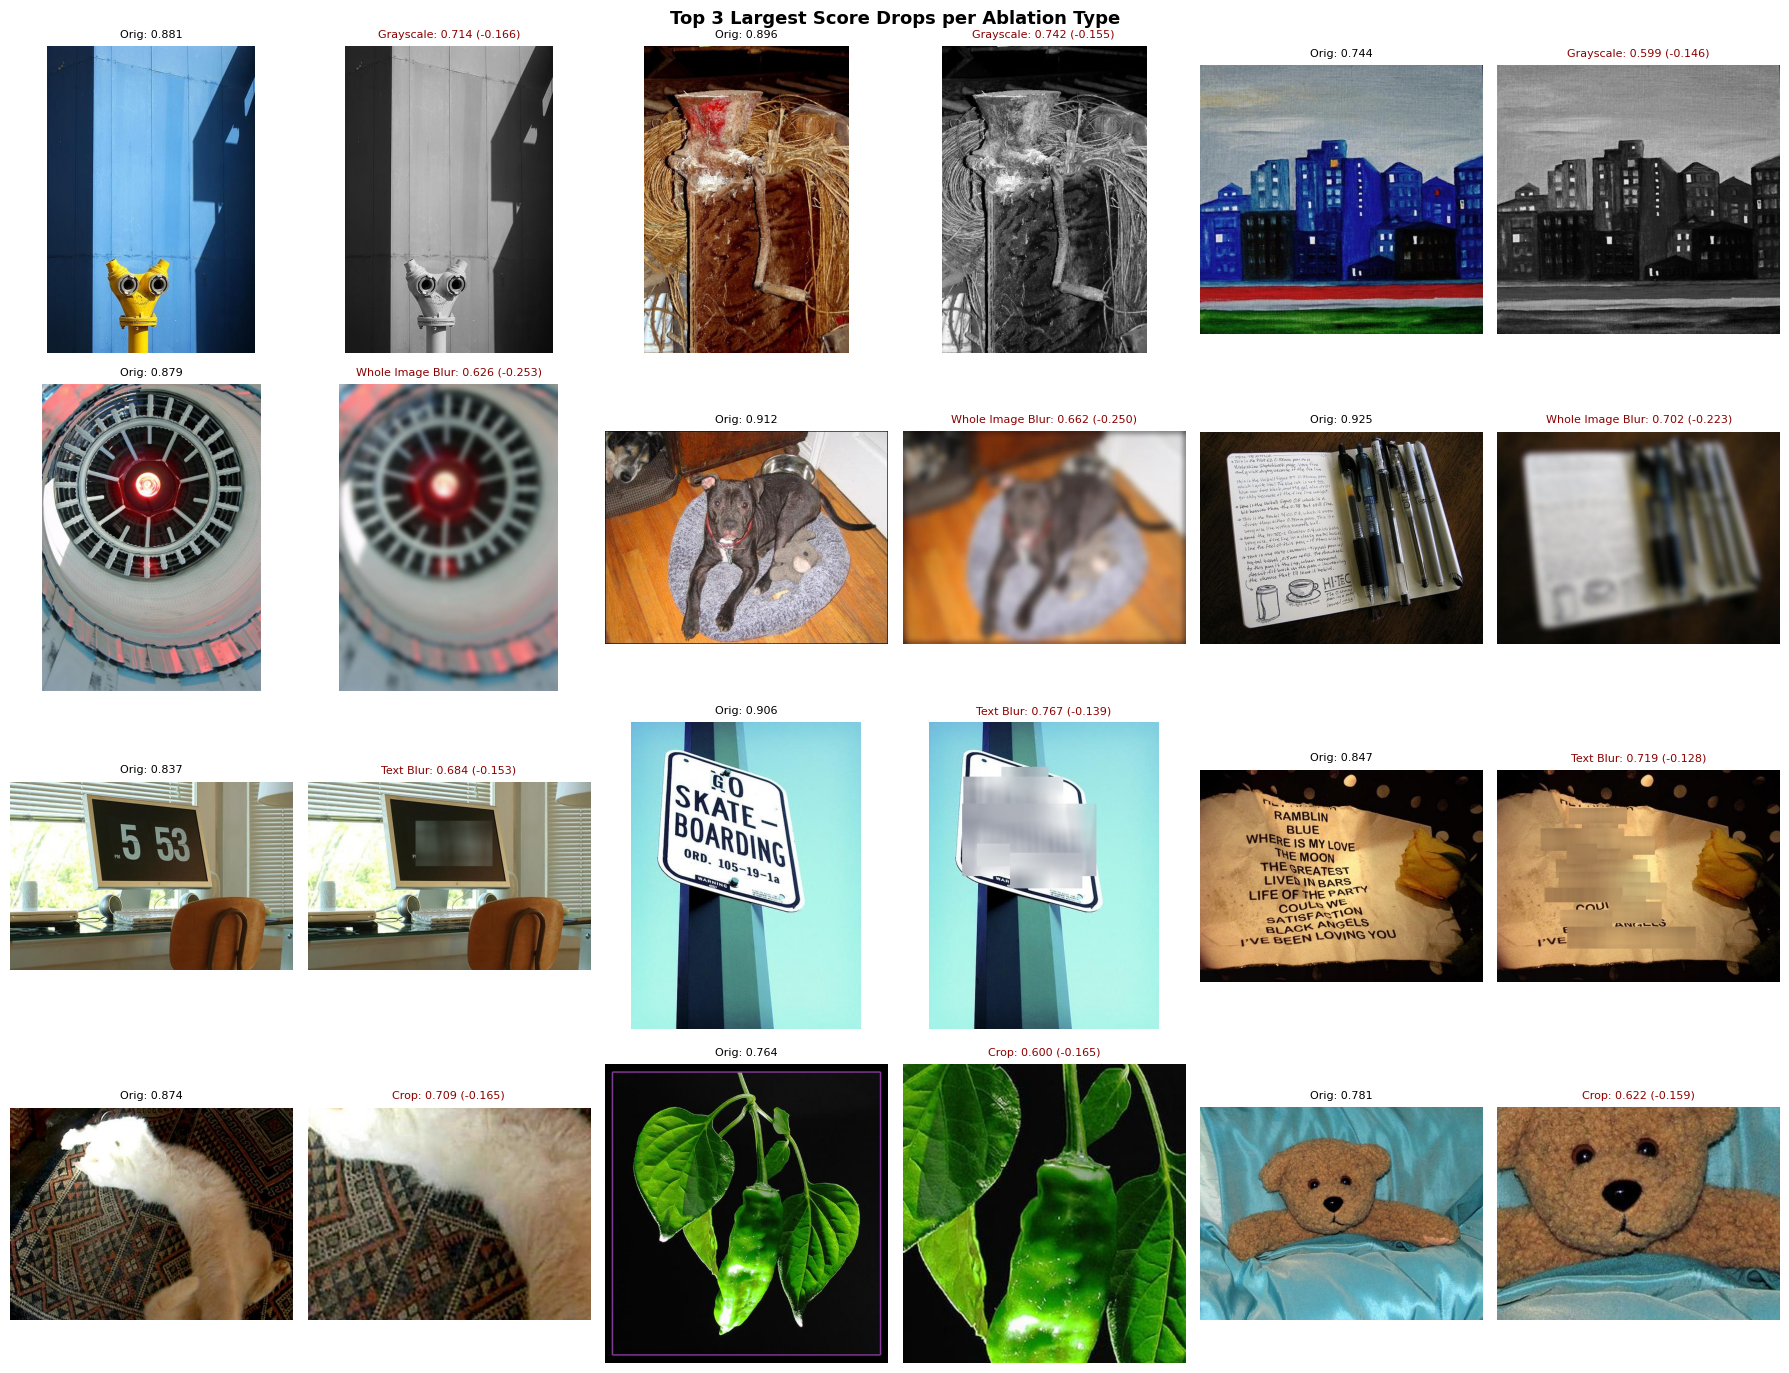

In [12]:
# ── FIGURE 5: Visual examples — top 3 biggest drops per ablation ─────
fig, axes = plt.subplots(4, 6, figsize=(18, 14))

for row_idx, (name, df) in enumerate(all_results.items()):
    top3 = df.nsmallest(3, 'delta')
    for col_idx, (_, r) in enumerate(top3.iterrows()):
        # Original
        orig = Image.open(os.path.join(ORIG_DIR, r['filename'])).convert('RGB')
        axes[row_idx, col_idx * 2].imshow(orig)
        axes[row_idx, col_idx * 2].set_title(f"Orig: {r['original']:.3f}", fontsize=8)
        axes[row_idx, col_idx * 2].axis('off')
        # Ablated
        abl = Image.open(os.path.join(ABLATION_DIRS[name], r['filename'])).convert('RGB')
        axes[row_idx, col_idx * 2 + 1].imshow(abl)
        axes[row_idx, col_idx * 2 + 1].set_title(
            f"{LABELS[name]}: {r['ablated']:.3f} ({r['delta']:+.3f})",
            fontsize=8, color='darkred'
        )
        axes[row_idx, col_idx * 2 + 1].axis('off')

fig.suptitle('Top 3 Largest Score Drops per Ablation Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig5_top_drops.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── STATISTICAL SUMMARY ───────────────────────────────────────────────
print(f"{'Ablation':<18} {'N':>5} {'Mean Orig':>10} {'Mean Abl':>10} {'Mean Δ':>10} {'Std Δ':>8} {'% Drop':>8} {'p-value':>10} {'Sig':>5}")
print("-" * 90)

for name, df in all_results.items():
    t, p      = stats.ttest_rel(df['original'], df['ablated'])
    pct_drop  = (df['delta'] < 0).mean() * 100
    sig       = "*" if p < 0.05 else ""
    print(f"{LABELS[name]:<18} {len(df):>5} {df['original'].mean():>10.4f} "
          f"{df['ablated'].mean():>10.4f} {df['delta'].mean():>+10.4f} "
          f"{df['delta'].std():>8.4f} {pct_drop:>7.1f}% {p:>10.4f} {sig:>5}")

print("\n* = statistically significant at α = 0.05 (paired t-test)")

Ablation               N  Mean Orig   Mean Abl     Mean Δ    Std Δ   % Drop    p-value   Sig
------------------------------------------------------------------------------------------
Grayscale           1000     0.7362     0.7451    +0.0089   0.0516    44.4%     0.0000     *
Whole Image Blur    1000     0.7362     0.7271    -0.0091   0.0737    53.8%     0.0001     *
Text Blur            999     0.7360     0.7361    +0.0001   0.0172    48.0%     0.8311      
Crop                1000     0.7362     0.7382    +0.0020   0.0629    47.8%     0.3108      

* = statistically significant at α = 0.05 (paired t-test)
